Task 1 : MCP Neurons

In [4]:
# AND Gate

def MCP_Neurons_AND(X1, X2, T):
    assert len(X1) == len(X2)

    state_neuron = []

    # Element-wise addition and threshold check
    for x1, x2 in zip(X1, X2):
        total = x1 + x2
        if total >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron

In [5]:
# Example usage
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 2

result = MCP_Neurons_AND(X1, X2, T)
print("AND Output:", result)

AND Output: [0, 0, 0, 1]


In [6]:
# OR Gate
def MCP_Neurons_OR(X1, X2, T):
    assert len(X1) == len(X2)

    state_neuron = []

    for x1, x2 in zip(X1, X2):
        total = x1 + x2
        if total >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron

In [7]:
# Example usage
T = 1
result_or = MCP_Neurons_OR(X1, X2, T)
print("OR Output:", result_or)

OR Output: [0, 1, 1, 1]


# Limitations of MCP Neurons:
1.   It can only solve linearly separable problems and fails on non-linear problems like XOR.
2.   It has no learning capability since weights and threholds are fixed manually.
3. It produces only binaryv outputs (0 or 1), limiting its use in continuous tasks.
4. Gradient-based learning cannot be applied since it uses non-differentiable step function.
5. It does not support hidden layers resttricting it to simple single-layer methods.






# Think if you can develop a logic to solve for XOR function using MCP Neuron.

Yes, XOR can be implemented using MCP neurons by designing logical if–else rules, even though a single MCP neuron cannot solve it directly because XOR is not linearly separable. The XOR function outputs 1 only when the two inputs are different, so we can define the logic as: if both inputs are 0, the output is 0; if both inputs are 1, the output is also 0; otherwise, the output is 1. This can also be expressed more simply as: if (x_1 \neq x_2), then output is 1, else output is 0. In terms of MCP neuron logic, XOR can be constructed by combining multiple neurons to compute intermediate functions like OR and AND, and then applying the rule ( \text{XOR} = (x_1 \text{ OR } x_2) \text{ AND NOT } (x_1 \text{ AND } x_2) ). Thus, while a single MCP neuron fails, a network of MCP neurons using structured logical rules can successfully represent the XOR function.



# Understanding Perceptron and Perceptron Learning Algorithm.

## Solving "OR" Function with Perceptron.

In [8]:
import numpy as np

class Perceptron:
    """
    A simple Perceptron classifier for binary classification.

    Attributes:
    -----------
    weights : np.ndarray
        Array of weights including the bias term, initialized randomly.
    learning_rate : float
        The step size for weight updates.
    epochs : int
        The number of training iterations over the dataset.

    Methods:
    --------
    step_function(z)
        Activation function that returns 1 if z >= 0, else 0.

    predict(x)
        Predicts the output for a given input sample x.

    train(X, Y)
        Trains the perceptron on the given dataset (X: inputs, Y: target labels).

    Example:
    --------
    >>> X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
    >>> Y = np.array([0, 1, 1, 1])  # OR function
    >>> perceptron = Perceptron(input_size=2, learning_rate=0.1, epochs=10)
    >>> perceptron.train(X, Y)
    >>> print(perceptron.predict([1, 1]))  # Expected output: 1
    """

    def __init__(self, input_size, learning_rate=0.1, epochs=10):
        """
        Initializes the perceptron with small random weights.

        Parameters:
        -----------
        input_size : int
            Number of input features.
        learning_rate : float, optional (default=0.1)
            Step size for weight updates.
        epochs : int, optional (default=10)
            Number of times to iterate over the dataset.
        """
        self.weights = np.random.rand(input_size + 1) * 0.2 - 0.1  # Small random weights
        self.learning_rate = learning_rate
        self.epochs = epochs

    def step_function(self, z):
        """
        Step activation function.

        Parameters:
        -----------
        z : float
            Weighted sum of inputs and weights.

        Returns:
        --------
        int
            1 if z >= 0, else 0.
        """
        return 1 if z >= 0 else 0

    def predict(self, x):
        """
        Predicts the output for a given input sample.

        Parameters:
        -----------
        x : array-like
            Input feature vector.

        Returns:
        --------
        int
            Predicted class label (0 or 1).
        """
        x = np.insert(x, 0, 1)  # Bias term
        z = np.dot(self.weights, x)
        return self.step_function(z)

    def train(self, X, Y):
        """
        Trains the perceptron using the perceptron learning rule.

        Parameters:
        -----------
        X : np.ndarray
            Training data (each row is an input sample).
        Y : np.ndarray
            Corresponding target labels (0 or 1).

        Prints:
        -------
        Updates the weights and prints them after each epoch.
        """
        X = np.c_[np.ones(X.shape[0]), X]  # Add bias term to input
        for epoch in range(self.epochs):
            for i in range(X.shape[0]):
                z = np.dot(self.weights, X[i])
                y_pred = self.step_function(z)
                error = Y[i] - y_pred
                self.weights += self.learning_rate * error * X[i]
            print(f"Epoch {epoch+1}, Weights: {self.weights}")


In [9]:
# Example usage with adjustable input size
learning_rate = 0.1
epochs = 10
input_size = 3

# Create training data (modify as needed for different functions and input sizes)
X = np.array([
    [0, 0, 0],
    [0, 0, 1],
    [0, 1, 0],
    [0, 1, 1],
    [1, 0, 0],
    [1, 0, 1],
    [1, 1, 0],
    [1, 1, 1],
])

# Example: OR function with 3 inputs
Y = np.array([0, 1, 1, 1, 1, 1, 1, 1])

# Initialize and train the perceptron
perceptron = Perceptron(input_size, learning_rate=learning_rate, epochs=epochs)
perceptron.train(X, Y)


# Test the perceptron
test_samples = X  # Use the same training samples for testing
print("\nPredictions:")
for sample in test_samples:
    print(f"Input: {sample}, Prediction: {perceptron.predict(sample)}")

Epoch 1, Weights: [0.14058245 0.0316935  0.0252326  0.02397658]
Epoch 2, Weights: [0.04058245 0.0316935  0.0252326  0.02397658]
Epoch 3, Weights: [0.04058245 0.0316935  0.0252326  0.12397658]
Epoch 4, Weights: [0.04058245 0.0316935  0.1252326  0.12397658]
Epoch 5, Weights: [0.04058245 0.1316935  0.1252326  0.12397658]
Epoch 6, Weights: [-0.05941755  0.1316935   0.1252326   0.12397658]
Epoch 7, Weights: [-0.05941755  0.1316935   0.1252326   0.12397658]
Epoch 8, Weights: [-0.05941755  0.1316935   0.1252326   0.12397658]
Epoch 9, Weights: [-0.05941755  0.1316935   0.1252326   0.12397658]
Epoch 10, Weights: [-0.05941755  0.1316935   0.1252326   0.12397658]

Predictions:
Input: [0 0 0], Prediction: 0
Input: [0 0 1], Prediction: 1
Input: [0 1 0], Prediction: 1
Input: [0 1 1], Prediction: 1
Input: [1 0 0], Prediction: 1
Input: [1 0 1], Prediction: 1
Input: [1 1 0], Prediction: 1
Input: [1 1 1], Prediction: 1


## Trying for "XOR" Function.

In [10]:
import numpy as np

class Perceptron:
    """
    A simple implementation of a Perceptron for binary classification.

    This perceptron learns a linear decision boundary using the Perceptron Learning Rule.
    It can be used to classify linearly separable datasets such as AND, OR, but not XOR.

    Attributes:
    -----------
    weights : np.ndarray
        Weight vector including the bias term, initialized randomly.
    learning_rate : float
        The step size for weight updates during training.
    epochs : int
        Number of times the entire dataset is passed through during training.

    Methods:
    --------
    step_function(z)
        Applies a step activation function (returns 1 if z >= 0, else 0).

    predict(x)
        Predicts the class label for a given input sample.

    train(X, Y)
        Trains the perceptron on a given dataset by updating weights iteratively.

    Example:
    --------
    >>> X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
    >>> Y = np.array([0, 1, 1, 1])  # OR function
    >>> perceptron = Perceptron(input_size=2, learning_rate=0.1, epochs=10)
    >>> perceptron.train(X, Y)
    >>> print(perceptron.predict([1, 1]))  # Expected output: 1
    """

    def __init__(self, input_size, learning_rate=0.1, epochs=10):
        """
        Initializes the perceptron model.

        Parameters:
        -----------
        input_size : int
            Number of input features (excluding the bias term).
        learning_rate : float, optional (default=0.1)
            Step size for weight updates.
        epochs : int, optional (default=10)
            Number of training iterations over the dataset.
        """
        self.weights = np.random.rand(input_size + 1) * 0.2 - 0.1  # Small random weights
        self.learning_rate = learning_rate
        self.epochs = epochs

    def step_function(self, z):
        """
        Step activation function.

        Parameters:
        -----------
        z : float
            Weighted sum of inputs and weights.

        Returns:
        --------
        int
            1 if z >= 0, else 0.
        """
        return 1 if z >= 0 else 0

    def predict(self, x):
        """
        Predicts the output for a given input sample.

        Parameters:
        -----------
        x : array-like
            Input feature vector (excluding bias).

        Returns:
        --------
        int
            Predicted class label (0 or 1).
        """
        x = np.insert(x, 0, 1)  # Insert bias term at the beginning
        z = np.dot(self.weights, x)
        return self.step_function(z)

    def train(self, X, Y):
        """
        Trains the perceptron using the perceptron learning algorithm.

        Parameters:
        -----------
        X : np.ndarray
            Training data, where each row represents an input sample.
        Y : np.ndarray
            Target labels corresponding to the input samples (0 or 1).

        Prints:
        -------
        Updates the weights and prints them after each epoch.
        """
        X = np.c_[np.ones(X.shape[0]), X]  # Add bias term to input
        for epoch in range(self.epochs):
            for i in range(X.shape[0]):
                z = np.dot(self.weights, X[i])
                y_pred = self.step_function(z)
                error = Y[i] - y_pred
                self.weights += self.learning_rate * error * X[i]
            print(f"Epoch {epoch+1}, Weights: {self.weights}")


In [11]:
# XOR data
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
Y = np.array([0, 1, 1, 0])  # XOR target

# Initialize and train the perceptron
input_size = X.shape[1]
perceptron = Perceptron(input_size, epochs=100)  # Increased epochs for demonstration
perceptron.train(X, Y)

# Test the perceptron
print("\nXOR Predictions:")
for i in range(len(X)):
    print(f"Input: {X[i]}, Prediction: {perceptron.predict(X[i])}, Target: {Y[i]}")


Epoch 1, Weights: [ 0.0089394  -0.09449789  0.0742215 ]
Epoch 2, Weights: [ 0.0089394  -0.09449789  0.0742215 ]
Epoch 3, Weights: [ 0.0089394  -0.09449789  0.0742215 ]
Epoch 4, Weights: [ 0.0089394  -0.09449789  0.0742215 ]
Epoch 5, Weights: [ 0.0089394  -0.09449789  0.0742215 ]
Epoch 6, Weights: [ 0.0089394  -0.09449789  0.0742215 ]
Epoch 7, Weights: [ 0.0089394  -0.09449789  0.0742215 ]
Epoch 8, Weights: [ 0.0089394  -0.09449789  0.0742215 ]
Epoch 9, Weights: [ 0.0089394  -0.09449789  0.0742215 ]
Epoch 10, Weights: [ 0.0089394  -0.09449789  0.0742215 ]
Epoch 11, Weights: [ 0.0089394  -0.09449789  0.0742215 ]
Epoch 12, Weights: [ 0.0089394  -0.09449789  0.0742215 ]
Epoch 13, Weights: [ 0.0089394  -0.09449789  0.0742215 ]
Epoch 14, Weights: [ 0.0089394  -0.09449789  0.0742215 ]
Epoch 15, Weights: [ 0.0089394  -0.09449789  0.0742215 ]
Epoch 16, Weights: [ 0.0089394  -0.09449789  0.0742215 ]
Epoch 17, Weights: [ 0.0089394  -0.09449789  0.0742215 ]
Epoch 18, Weights: [ 0.0089394  -0.09449

In [12]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [13]:
# Load the dataset

import pandas as pd
import numpy as np

df = pd.read_csv('/content/drive/MyDrive/AI ML/Data/mnist_3_and_5.csv')

In [14]:
# Features and labels

X = df.drop(columns=['label']).values
y = df['label'].values

print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

Feature matrix shape: (2741, 784)
Label vector shape: (2741,)


In [15]:
# Convert labels to binary
# 3 to 0 and 5 to 1

y = np.where(y == 3, 0, y)
y = np.where(y == 5, 1, y)

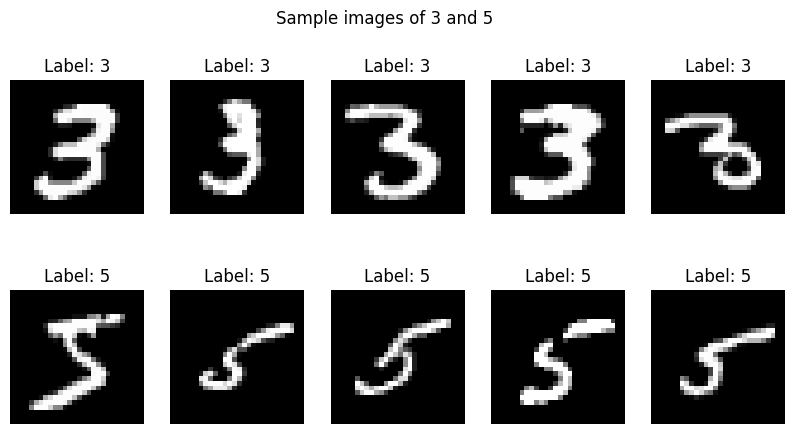

In [16]:
# Visualize digits

import matplotlib.pyplot as plt

images_3 = X[y == 0]
images_5 = X[y == 1]

fig, axes = plt.subplots(2, 5, figsize=(10,5))

for i in range(5):
  axes[0, i].imshow(images_3[i].reshape(28,28), cmap="gray")
  axes[0, i].set_title("Label: 3")
  axes[0, i].axis("off")

  axes[1, i].imshow(images_5[i].reshape(28,28), cmap="gray")
  axes[1, i].set_title("Label: 5")
  axes[1, i].axis("off")

plt.suptitle("Sample images of 3 and 5")
plt.show()

In [17]:
# Initialize weights

weights = np.zeros(X.shape[1])
bias = 0
learning_rate = 0.1
epochs = 100

# What does weights array represnt in this context?

The weights arrray represnts the importance of each input feature (pixel) to the final prediction; since there are 784 pixels, each weight corresponds to one pixel and determines how strongly that pixel influences the model's output.

# Why are we initializing the weights to zero and its effect?

We initialize the weights to zero for simplicity and a neutral starting point, meaning no feature is initially preferred; however, this can be problematic in more complex models (like multi-layer networks) because all neurons may learn the same thing (symmetry problem), though in simple models like a perceptron or logistsic regression it can still work but may slow down learning or limit effective feature differentiation initially.

In [18]:
# Decision function

def decision_function(X, Weights, bias):
  """
  Compute the predicted labels for the input data.

  Parameters:
  - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - weights: Updated weights after training
    - bias: Updated bias after training

    Returns:
    - y_pred_all: The predicted labels for the input data
  """
  predictions = np.dot(X, weights) + bias
  y_pred_all = np.where(predictions >= 0, 1, 0)
  return y_pred_all

# What is the purpose of the output = np.dot(X[i], weights) + bias line?

This line computes the weighted sum of input fetaures plus bias, which represents the model's decision score for a given inout; it determines wheteher the output should be classifies as 0 or 1 based on the threshold.

# What happens when the prediction is wrong? How are weights and bias updated?

When the prediction is incorrect, the model updates it paarmeters using the perceptron learning rule; the weights are adjusted by adding (learning_rate * error * input) and the bias is updated by adding (learning_rate * error), where error = (actual - predicted), helping the model correct its mistake.

# Why is the final accuracy important, and what do you expect it to be?

Final accuacy measures how well teh model performs on teh data, indicating its effectiveness in making correct predictions; ideally, we expect a high accuracy (close to 100%) on training data if the problem is linearly sepaarble, though real-world performance may be slightly lower.

Implement the perceptron learning algorithm

In [19]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
  """
  Train the perceptron using the perceptron learning algorithm.

  Parameters:
  - X: Features (input data)as numpy array of shape (n_samples, n_features)
  - y: Labels (true output) as numpy array of shape (n_samples,)
  - weights: Initial weights as nump array of cshape (n_features)
  - bias : Initial bias value (scalar)
  - learning_rate : learning rate for weight updates (default is 0.1)
  - epochs : Number of iterations to train the model (default is 100)

  Returns:
  - weights: updated weights after ttraining
  - bias: updated bias after training
  - accuracy: total corrcet predictions
  """

  # Perceptron learning algorithm
  for epoch in range(epochs):

    #for each epocch we iterate through each data points
    for i in range(len(X)):
      # Calcualte the predicted output (y_pred)
      prediction = np.dot(X[i], weights) + bias
      y_pred = np.where(prediction >= 0, 1, 0)

      # Update teh weight and bias
      # the update rule is : weight = weight + learning_rate * (true_output - predicted_output) * input
      #                       bias = bias + learning_rate * (true_output - predicted_output)
      weights += learning_rate * (y[i] - y_pred) * X[i]
      bias += learning_rate * (y[i] - y_pred)

   # Calculate accuracy after each epoch
    final_predictions = np.dot(X, weights) + bias
    epoch_y_pred = np.where(final_predictions >= 0, 1, 0)
    accuracy = np.mean(epoch_y_pred == y)

   # Print accuracy every 10 epochs
    if (epoch + 1) % 10 == 0:
      print (f"Epoch {epoch + 1} : Accuracy = {accuracy : .4f}")

  return weights, bias, accuracy

TRaining the perceptron

In [20]:
# After training the model with the perceptron_learning_algorithm
weights, bias, accuracy = train_perceptron(X, y, weights, bias)

Epoch 10 : Accuracy =  0.9613
Epoch 20 : Accuracy =  0.9540
Epoch 30 : Accuracy =  0.9730
Epoch 40 : Accuracy =  0.9730
Epoch 50 : Accuracy =  0.9518
Epoch 60 : Accuracy =  0.9515
Epoch 70 : Accuracy =  0.9770
Epoch 80 : Accuracy =  0.9861
Epoch 90 : Accuracy =  0.9829
Epoch 100 : Accuracy =  0.9869


In [21]:
# Evaluate the model using teh new function
print ("the final accuracy is: ", accuracy)

the final accuracy is:  0.986866107260124


Visualize misclassified images

In [22]:
# get predictions for all data points
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

In [23]:
# Calcualte the final accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final accuarcy: {final_accuracy: .4f}")

Final accuarcy:  0.9869


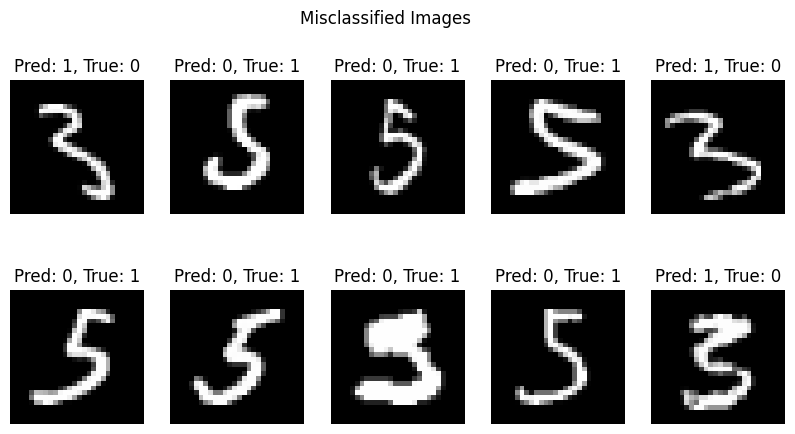

In [24]:
# Visualize misclassified images
misclassified_idx = np.where(y_pred != y)[0]
if len(misclassified_idx) > 0:
  fig, axes = plt.subplots(2, 5, figsize=(10,5))
  for ax, idx in zip(axes.flat, misclassified_idx[:10]): # Show 10 misclassified images
    ax.imshow(X[idx].reshape(28,28), cmap="gray")
    ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
    ax.axis("off")
  plt.suptitle("Misclassified Images")
  plt.show()
else:
  print("All images were correctly classified")

# What does misclassified idx store, and how is it used in this code?

misclassified_idx stores the indices of all data points where the predicted labels (y_pred) do not match the true labels (y), and it is used to select and display those misclassified images so we can visually analyze where the model made mistakes.

# How do you interpret “All images were correctly classified!”?

This means that there are no mismatches between predictions and actual labels, so the model achieved 100% accuracy on the given dataset, indicating perfect classification (at least on that data).